## **Hepatitis C Virus (HCV) for Egyptian patients**

Group members :
Rachel SHERPA, Estelle SOBESKY, Koralie THERESINE, Yasmine ZEROUAL

**STEP 1 - Import libraries and load the dataset**

In [110]:
!pip install ucimlrepo
!pip install xgboost lightgbm


# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel,RFE, mutual_info_classif, chi2
from sklearn.decomposition import PCA

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import ( BaggingClassifier, VotingClassifier)


# evaluation
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, f1_score,ConfusionMatrixDisplay,roc_auc_score, roc_curve)
from sklearn.metrics import recall_score


# imbalanced data
from collections import Counter
from imblearn.over_sampling import SMOTE
#from imblearn.over_sampling import RandomOverSampler
#from imblearn.under_sampling import RandomUnderSampler

# import the function to load datasets from the UCI repository
from ucimlrepo import fetch_ucirepo






# Informations on the dataset

The dataset used in this project is the Hepatitis C Virus (HCV) for Egyptian patients dataset, obtained from the UCI Machine Learning Repository.

It contains clinical, demographic and laboratory information from 1385 Egyptian patients infected with the Hepatitis C Virus (HCV).
Each record included variables such as age, BMI, blood test results, RNA measurements collected at different treatment stages.

The target variable, called Baseline Histological Staging, represents the stage of liver fibrosis (F0-F3), which indicates the progression of liver damage in HCV patients.
The goal of this dataset is to enable the prediction of the fibrosis stage based on these medical features.

This topic was chosen because Hepatitis C remains a major public health issue in many countries, and using machine learning models to predict liver fibrosis can help improve early diagnosis and patient management. It has a real impact on the world.

**STEP 2 - Load the dataset**

In [114]:
# ML tools
from ucimlrepo import fetch_ucirepo

# Fetch dataset (UCI id = 503)
hcv = fetch_ucirepo(id=503)

# Extract features and target
X = hcv.data.features
y = hcv.data.targets

# Merge for easier exploration
df = pd.concat([X, y], axis=1)

# Quick overview
print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape of dataset: (1385, 29)
Columns: ['Age ', 'Gender', 'BMI', 'Fever', 'Nausea/Vomting', 'Headache ', 'Diarrhea ', 'Fatigue & generalized bone ache ', 'Jaundice ', 'Epigastric pain ', 'WBC', 'RBC', 'HGB', 'Plat', 'AST 1', 'ALT 1', 'ALT4', 'ALT 12', 'ALT 24', 'ALT 36', 'ALT 48', 'ALT after 24 w', 'RNA Base', 'RNA 4', 'RNA 12', 'RNA EOT', 'RNA EF', 'Baseline histological Grading', 'Baselinehistological staging']


,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,WBC,RBC,HGB,Plat,AST 1,ALT 1,ALT4,ALT 12,ALT 24,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
0,56,1,35,2,1,1,1,2,2,2,7425,4248807.0,14,112132.0,99,84,52.0,109,81,5,5,5,655330,634536,288194,5,5,13,2
1,46,1,29,1,2,2,1,2,2,1,12101,4429425.0,10,129367.0,91,123,95.0,75,113,57,123,44,40620,538635,637056,336804,31085,4,2
2,57,1,33,2,2,2,2,1,1,1,4178,4621191.0,12,151522.0,113,49,95.0,107,116,5,5,5,571148,661346,5,735945,558829,4,4
3,49,2,33,1,2,1,2,1,2,1,6490,4794631.0,10,146457.0,43,64,109.0,80,88,48,77,33,1041941,449939,585688,744463,582301,10,3
4,59,1,32,1,1,2,1,2,2,2,3661,4606375.0,11,187684.0,99,104,67.0,48,120,94,90,30,660410,738756,3731527,338946,242861,11,1


This dataset contains mediacl data from 1 385 Egyptian patients infected with Hepatitis C virus (HCV). It includes demographic, clinical and laboratory features. The target variable is Baseline Histological Staging, which represents the level of liver fibrosis and is divided into four stages :

- stage 1 : mild fibrosis
- stage 2 : moderate fibrosis
- stage 3 : severe fibrosis
- stage 4 : advanced fibrosis


We clean the variable names because some of them contain spaces, which can cause error during the discretization.

In [117]:
# Clean column names : remove spaces and make them consistent
df.columns = (
    df.columns
      .str.strip() # remove leading and trailing spaces
      .str.replace(" ", "_") # replace spaces with underscores
      .str.replace("/", "_") # replace slashes if present
      .str.replace("&", "and")
      .str.lower()  # convert to lowercase
)

# Check column names
print(df.columns.tolist())

['age', 'gender', 'bmi', 'fever', 'nausea_vomting', 'headache', 'diarrhea', 'fatigue_and_generalized_bone_ache', 'jaundice', 'epigastric_pain', 'wbc', 'rbc', 'hgb', 'plat', 'ast_1', 'alt_1', 'alt4', 'alt_12', 'alt_24', 'alt_36', 'alt_48', 'alt_after_24_w', 'rna_base', 'rna_4', 'rna_12', 'rna_eot', 'rna_ef', 'baseline_histological_grading', 'baselinehistological_staging']


**STEP 3 — Descriptive analysis of your data (EDA)**

In [119]:
# Basic info about the dataset
print("General information")
df.info()

# Descriptive statistics
print("\n Statistical summary")
display(df.describe())

# Check for missing values
print("\n Missing values per column")
missing_values = df.isna().sum()
display(missing_values[missing_values > 0])
print(df.isnull().sum())

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")



General information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                1385 non-null   int64  
 1   gender                             1385 non-null   int64  
 2   bmi                                1385 non-null   int64  
 3   fever                              1385 non-null   int64  
 4   nausea_vomting                     1385 non-null   int64  
 5   headache                           1385 non-null   int64  
 6   diarrhea                           1385 non-null   int64  
 7   fatigue_and_generalized_bone_ache  1385 non-null   int64  
 8   jaundice                           1385 non-null   int64  
 9   epigastric_pain                    1385 non-null   int64  
 10  wbc                                1385 non-null   int64  
 11  rbc                                1

,age,gender,bmi,fever,nausea_vomting,headache,diarrhea,fatigue_and_generalized_bone_ache,jaundice,epigastric_pain,wbc,rbc,hgb,plat,ast_1,alt_1,alt4,alt_12,alt_24,alt_36,alt_48,alt_after_24_w,rna_base,rna_4,rna_12,rna_eot,rna_ef,baseline_histological_grading,baselinehistological_staging
count,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1.385000e+03,1385.000000,1385.00000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1.385000e+03,1.385000e+03,1.385000e+03,1385.000000,1385.000000,1385.000000,1385.000000
mean,46.319134,1.489531,28.608664,1.515523,1.502527,1.496029,1.502527,1.498917,1.501083,1.503971,7533.386282,4.422130e+06,12.587726,158348.06065,82.774729,83.916245,83.405776,83.510469,83.709025,83.117690,83.629603,33.438267,5.909512e+05,6.008956e+05,2.887536e+05,287660.336462,291378.290975,9.761733,2.536462
std,8.781506,0.500071,4.076215,0.499939,0.500174,0.500165,0.500174,0.500179,0.500179,0.500165,2668.220333,3.463577e+05,1.713511,38794.78555,25.993242,25.922800,26.529730,26.064478,26.205994,26.399031,26.223955,7.073569,3.539354e+05,3.623151e+05,2.853507e+05,264559.525070,267700.691713,4.023896,1.121392
min,32.000000,1.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2991.000000,3.816422e+06,10.000000,93013.00000,39.000000,39.000000,39.000000,39.000000,39.000000,5.000000,5.000000,5.000000,1.100000e+01,5.000000e+00,5.000000e+00,5.000000,5.000000,3.000000,1.000000
25%,39.000000,1.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5219.000000,4.121374e+06,11.000000,124479.00000,60.000000,62.000000,61.000000,60.000000,61.000000,61.000000,61.000000,28.000000,2.692530e+05,2.708930e+05,5.000000e+00,5.000000,5.000000,6.000000,2.000000
50%,46.000000,1.000000,29.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,7498.000000,4.438465e+06,13.000000,157916.00000,83.000000,83.000000,82.000000,84.000000,83.000000,84.000000,83.000000,34.000000,5.931030e+05,5.978690e+05,2.343590e+05,251376.000000,244049.000000,10.000000,3.000000
75%,54.000000,2.000000,32.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,9902.000000,4.721279e+06,14.000000,190314.00000,105.000000,106.000000,107.000000,106.000000,107.000000,106.000000,106.000000,40.000000,8.867910e+05,9.090930e+05,5.248190e+05,517806.000000,527864.000000,13.000000,4.000000
max,61.000000,2.000000,35.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,12101.000000,5.018451e+06,15.000000,226464.00000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,45.000000,1.201086e+06,1.201715e+06,3.731527e+06,808450.000000,810333.000000,16.000000,4.000000



 Missing values per column


Series([], dtype: int64)

age                                  0
gender                               0
bmi                                  0
fever                                0
nausea_vomting                       0
headache                             0
diarrhea                             0
fatigue_and_generalized_bone_ache    0
jaundice                             0
epigastric_pain                      0
wbc                                  0
rbc                                  0
hgb                                  0
plat                                 0
ast_1                                0
alt_1                                0
alt4                                 0
alt_12                               0
alt_24                               0
alt_36                               0
alt_48                               0
alt_after_24_w                       0
rna_base                             0
rna_4                                0
rna_12                               0
rna_eot                  

There are no categorical columns in this dataset. All variables are numerical (continuous or discrete clinical measurements).
Therefore, we will only apply numerical preprocessing (scaling and imputation) in the next steps no encoding is required.

We first worked on the non-discretized dataset using a multi-class classification problem and tested several baseline models. The best accuracy we obtained was around 27%, which is quite low. Since the results were not satisfactory and no advanced models were used at this stage, we decided to apply feature discretization and reformulate the task as a binary classification problem in order to improve model performance.

**Discretization**

In [123]:
# copy the dataset for transformation
df_transformed = df.copy()

# discretization

df_transformed["age"] = pd.cut(df_transformed["age"], bins=[0, 32, 37, 42, 47, 52, 57, 62], right=False)
df_transformed["bmi"] = pd.cut(df_transformed["bmi"], bins=[0, 18.5, 25, 30, 35, 40], right=False)
df_transformed["wbc"] = pd.cut(df_transformed["wbc"], bins=[0, 4000, 11000, 12101], right=False)
df_transformed["rbc"] = pd.cut(df_transformed["rbc"], bins=[0, 3_000_000, 5_000_000, 5_018_451], right=False)
df_transformed["plat"] = pd.cut(df_transformed["plat"], bins=[0, 100_000, 255_000, 1_000_000_000], right=False)

# ALT/AST
alt_bins = [0, 20, 40, 140, 1_000_000]
for col in ["ast_1","alt_1","alt4","alt_12","alt_24","alt_36","alt_48"]:
    df_transformed[col] = pd.cut(df_transformed[col], bins=alt_bins, right=False)

# RNA
rna_bins = [0, 5, 1_500_000]
for col in ["rna_base","rna_4","rna_12","rna_eot","rna_ef"]:
    df_transformed[col] = pd.cut(df_transformed[col], bins=rna_bins, right=False)


# Remove duplicated columns
df_transformed = df_transformed.loc[:, ~df_transformed.columns.duplicated()]

# HGB depends on gender
df_transformed["hgb"] = np.where(
    df_transformed["gender"] == "Male",
    pd.cut(df_transformed["hgb"], bins=[0, 14, 17.5, 20], right=False),
    pd.cut(df_transformed["hgb"], bins=[0, 12.3, 15.3, 20], right=False))

# Categorical columns
categorical_cols = [
    "gender", "fever", "nausea_vomting", "headache", "diarrhea",
    "fatigue_and_generalized_bone_ache", "jaundice", "epigastric_pain",
    "age", "bmi", "wbc", "rbc", "plat", "hgb",
    "ast_1","alt_1","alt4","alt_12","alt_24","alt_36","alt_48",
    "rna_base","rna_4","rna_12","rna_eot","rna_ef"]

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df_transformed[categorical_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols), index=df_transformed.index)

# Remaining columns
non_cat_cols = [col for col in df_transformed.columns if col not in categorical_cols]
df_numerical = df_transformed[non_cat_cols]

# Final dataset
df_final = pd.concat([df_numerical, encoded_df], axis=1)


# Result
print("Shape final :", df_final.shape)
df_final.head()

# Final dataset
df_final = pd.concat([df_numerical, encoded_df], axis=1)

# Create a binary target (0 = early stages, 1 = advanced stages)
df_final["baseline_histological_staging_binary"] = df_final["baselinehistological_staging"].apply(lambda x: 0 if x in [1, 2] else 1)

# Drop the original multiclass target column
df_final = df_final.drop(columns=["baselinehistological_staging"])

# Check the class distribution
print("Binary target distribution:")
print(df_final["baseline_histological_staging_binary"].value_counts(normalize=True))


df_final.head()

Shape final : (1385, 62)
Binary target distribution:
baseline_histological_staging_binary
1    0.51769
0    0.48231
Name: proportion, dtype: float64


,alt_after_24_w,baseline_histological_grading,gender_1,gender_2,fever_1,fever_2,nausea_vomting_1,nausea_vomting_2,headache_1,headache_2,diarrhea_1,diarrhea_2,fatigue_and_generalized_bone_ache_1,fatigue_and_generalized_bone_ache_2,jaundice_1,jaundice_2,epigastric_pain_1,epigastric_pain_2,"age_[32, 37)","age_[37, 42)","age_[42, 47)","age_[47, 52)","age_[52, 57)","age_[57, 62)","bmi_[18.5, 25.0)","bmi_[25.0, 30.0)","bmi_[30.0, 35.0)","bmi_[35.0, 40.0)","wbc_[0.0, 4000.0)","wbc_[4000.0, 11000.0)","wbc_[11000.0, 12101.0)",wbc_nan,"rbc_[3000000.0, 5000000.0)","rbc_[5000000.0, 5018451.0)",rbc_nan,"plat_[0, 100000)","plat_[100000, 255000)","hgb_[0.0, 12.3)","hgb_[12.3, 15.3)","ast_1_[20, 40)","ast_1_[40, 140)","alt_1_[20, 40)","alt_1_[40, 140)","alt4_[20, 40)","alt4_[40, 140)","alt_12_[20, 40)","alt_12_[40, 140)","alt_24_[20, 40)","alt_24_[40, 140)","alt_36_[0, 20)","alt_36_[20, 40)","alt_36_[40, 140)","alt_48_[0, 20)","alt_48_[20, 40)","alt_48_[40, 140)","rna_base_[5, 1500000)","rna_4_[5, 1500000)","rna_12_[5.0, 1500000.0)",rna_12_nan,"rna_eot_[5, 1500000)","rna_ef_[5, 1500000)",baseline_histological_staging_binary
0,5,13,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0
1,44,4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0
2,5,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1
3,33,10,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1
4,30,11,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0


After discretization and one-hot encoding, the final dataset contains 1 385 samples and 62 features. All medical variables were transformed into categorical intervals, then encoded into binary features. The binary target variable shows a slight class imbalance with around 52% advanced stages (3-4) and 48% early stages (1-2).

**Display in the correct order**

In [126]:
import pandas as pd

# Show all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Reorder columns based on the original dataset order
original_order = [
    "Age", "Gender", "BMI", "Fever", "Nausea/Vomting", "Headache", "Diarrhea",
    "Fatigue & generalized bone ache ", "Jaundice", "Epigastric pain", "WBC", "RBC", "HGB", "Plat",
    "AST 1", "ALT 1", "ALT4", "ALT 12", "ALT 24", "ALT 36", "ALT 48", "ALT after 24 w",
    "RNA Base", "RNA 4", "RNA 12", "RNA EOT", "RNA EF",
    "Baseline histological Grading", "Baselinehistological staging"]

ordered_cols = []
for feature in original_order:
    matches = [col for col in df_final.columns if col.lower().startswith(feature.strip().lower().replace(" ", "_"))]
    ordered_cols.extend(matches)

remaining_cols = [col for col in df_final.columns if col not in ordered_cols]
final_order = ordered_cols + remaining_cols

# Reorder the dataset
df_final_ordered = df_final[final_order]
# Display the first rows to check the order
df_final_ordered.head()

# Identify duplicated columns if any
dups = df_final_ordered.columns[df_final_ordered.columns.duplicated()].tolist()

# Remove duplicated columns
df_final_ordered = df_final_ordered.loc[:, ~df_final_ordered.columns.duplicated()]


**STEP 1 — Split X and y**

In [128]:
# Select the target column
target_col = "baseline_histological_staging_binary"

# Check that the target column exists
assert target_col in df_final_ordered.columns, f"{target_col} n'existe pas dans df_final_ordered"

# Split features (X) and target (y)
X = df_final_ordered.drop(columns=[target_col])
y = df_final_ordered[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1385, 61)
y shape: (1385,)


**STEP 2 — Basic EDA on y**

C:\Users\ZEROUAL\AppData\Local\Temp\ipykernel_33744\4128845309.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


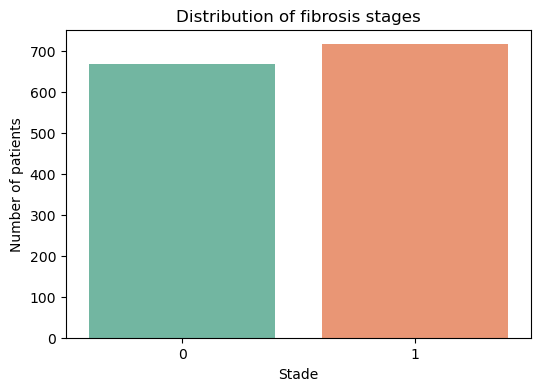

Raw distribution:
 baseline_histological_staging_binary
0    668
1    717
Name: count, dtype: int64

Proportions (%) :
 baseline_histological_staging_binary
0    48.23
1    51.77
Name: count, dtype: float64

Majority / minority ratio : 1.07


In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot of the target variable
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette="Set2")
plt.title("Distribution of fibrosis stages")
plt.xlabel("Stade")
plt.ylabel("Number of patients")
plt.show()

# Class counts
class_counts = y.value_counts().sort_index()
print("Raw distribution:\n", class_counts)

proportions = (class_counts / class_counts.sum() * 100).round(2)
print("\nProportions (%) :\n", proportions)

ratio = round(class_counts.max() / class_counts.min(), 2)
print("\nMajority / minority ratio :", ratio)


The target variable is almost balanced between the two classes. Early stages (0) represent about 48.23% of the patients, while advanced stages (1) represent about 51.77%. The majority/minority ratio is 1.07 which indicates a very slight imbalance. This means that class imbalance isn't an issue in this dataset, and we can apply models without using resampling techniques.

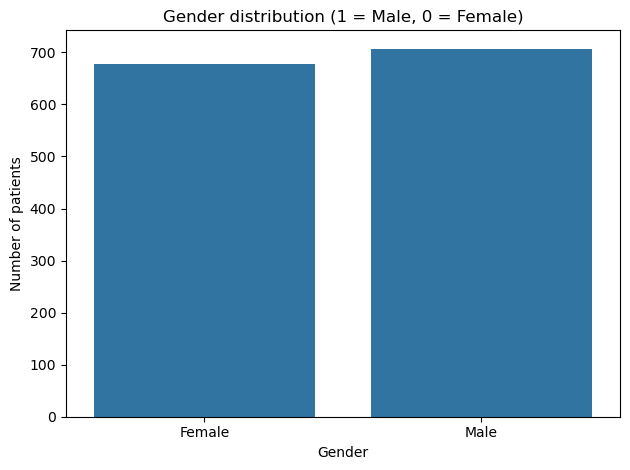

In [132]:
# Count plot of gender distribution
sns.countplot(x='gender_1', data=df_final_ordered)
plt.title("Gender distribution (1 = Male, 0 = Female)")
plt.xlabel("Gender")
plt.ylabel("Number of patients")
plt.xticks([0, 1], ['Female', 'Male'])
plt.tight_layout()
plt.show()

The gender distribution in the dataset is well balanced. The number of male and female patients is very similar, with a slight majority of male patients. This shows that the dataset provides a fair representation of both sexes for modeling.

C:\Users\ZEROUAL\AppData\Local\Temp\ipykernel_33744\1282627883.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_distribution.index, y=age_distribution.values, palette="Blues_d")


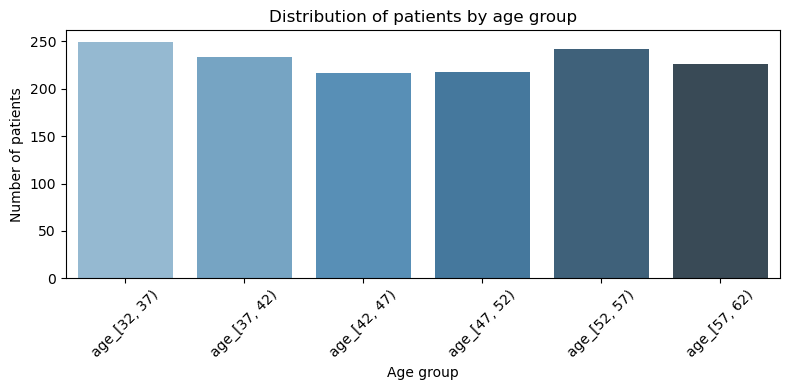

In [134]:
# Select age-related columns
age_cols = [col for col in df_final_ordered.columns if col.startswith("age_")]

# Compute the number of patients in each age group
age_distribution = df_final_ordered[age_cols].sum().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=age_distribution.index, y=age_distribution.values, palette="Blues_d")
plt.title("Distribution of patients by age group")
plt.xlabel("Age group")
plt.ylabel("Number of patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The age distribution shows that patients are fairly spread across all age groups. There is a slightly higher number of patients in the 32–37 and 52–57 age ranges, but there isn't an age group that dominates the dataset.This indicates that the model will be trained on a balanced representation of ages. It reduces the risk of age-related bias.

**STEP 3- Correlation analysis with the target**

C:\Users\ZEROUAL\AppData\Local\Temp\ipykernel_33744\352893778.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pos.values, y=top_pos.index, palette="crest")


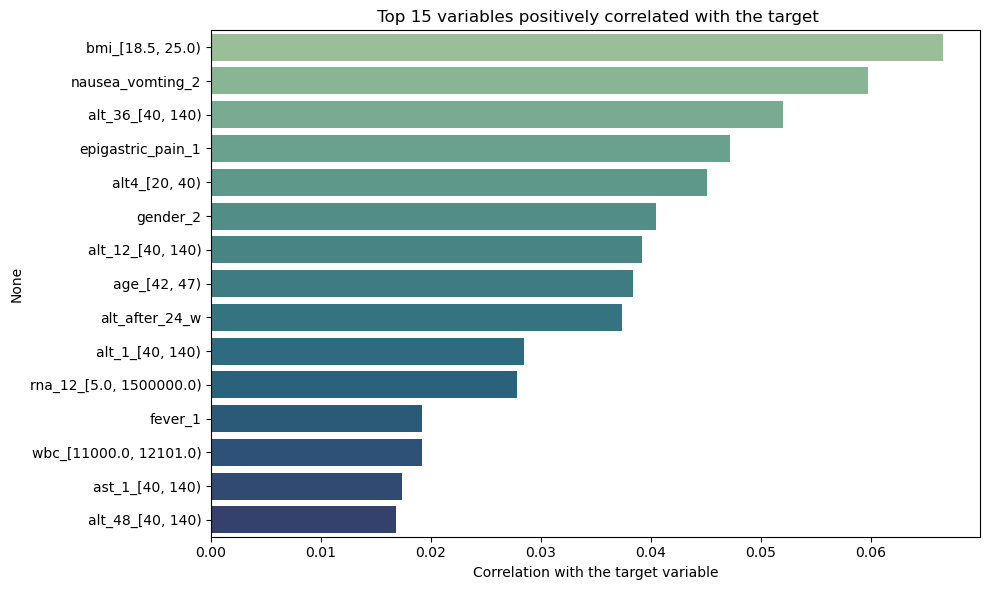

C:\Users\ZEROUAL\AppData\Local\Temp\ipykernel_33744\352893778.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neg.values, y=top_neg.index, palette="rocket")


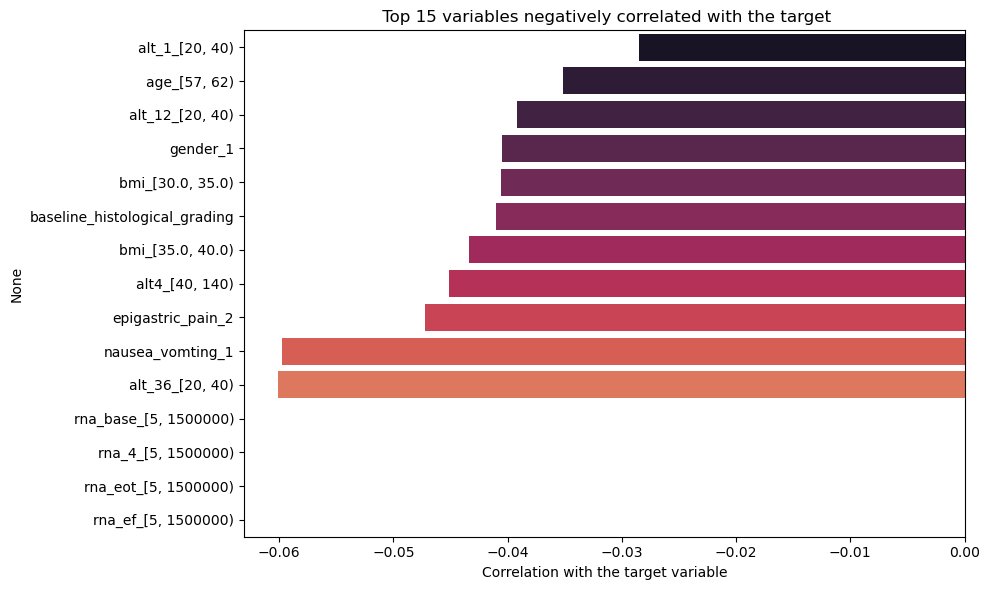

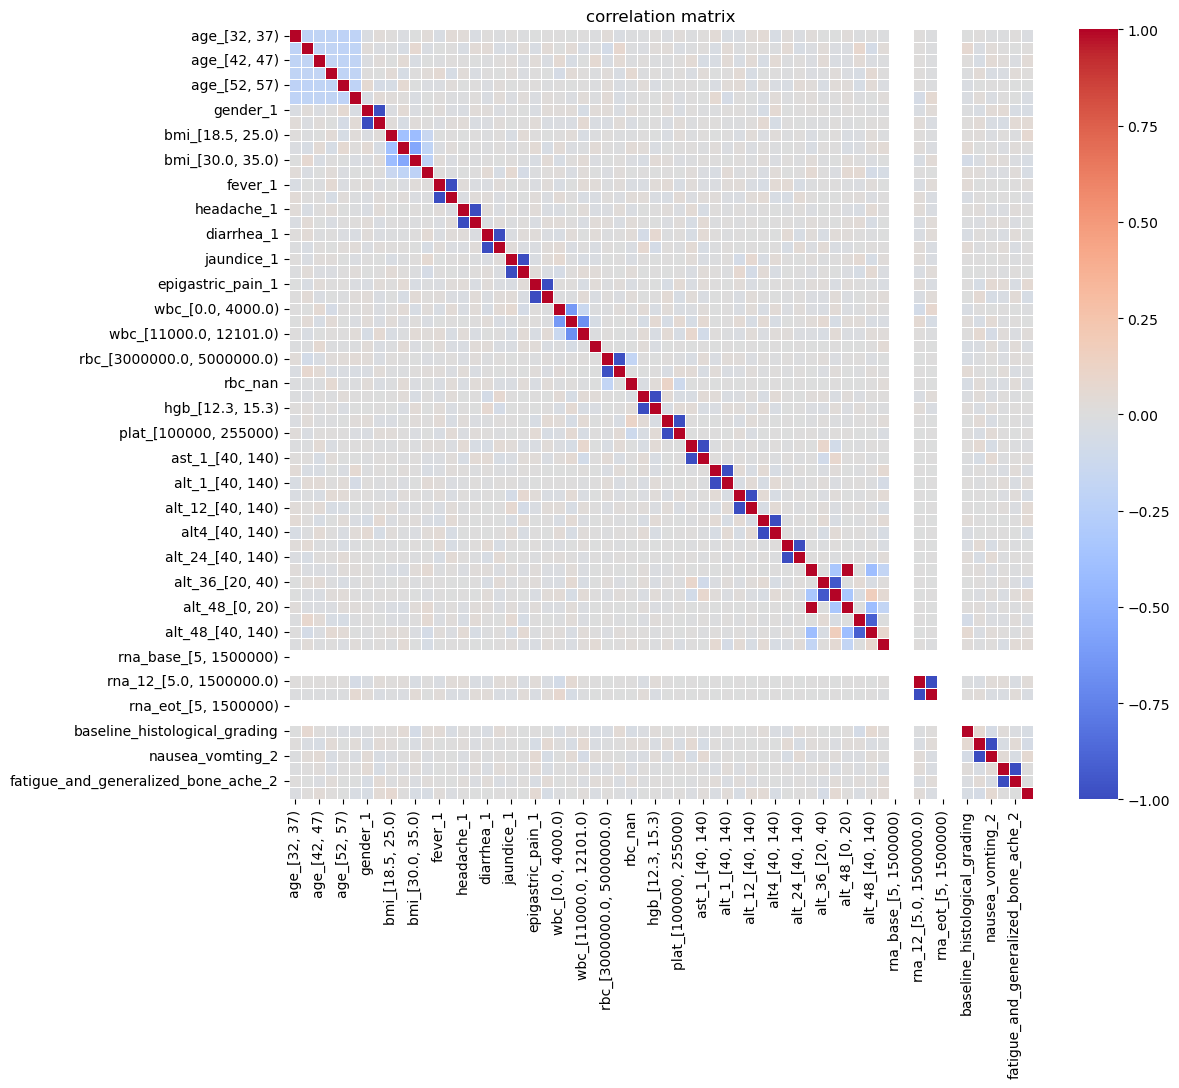

In [137]:
# Compute the correlation between each numerical variable and the target
correlations = df_final_ordered.corr(numeric_only=True)[target_col].drop(target_col)

# Sort correlations
top_corr = correlations.sort_values(ascending=False)

# Extract the 15 most and least correlated variables
top_pos = top_corr.head(15)
top_neg = top_corr.tail(15)

# Plot positive correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=top_pos.values, y=top_pos.index, palette="crest")
plt.title(" Top 15 variables positively correlated with the target")
plt.xlabel("Correlation with the target variable")
plt.tight_layout()
plt.show()

# Plot negative correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=top_neg.values, y=top_neg.index, palette="rocket")
plt.title(" Top 15 variables negatively correlated with the target")
plt.xlabel("Correlation with the target variable")
plt.tight_layout()
plt.show()

#Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df_final_ordered.corr(numeric_only=True), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("correlation matrix")
plt.show()



The correlation analysis shows that several biological and clinical variables are associated with fibrosis stage. Some ALT levels, BMI ranges, RNA measurements, and symptoms are positively correlated with advanced stages,while other ranges are more common in early stages. We see that correlations are moderate, indicating that fibrosis stage depends on a combination of features and not only on a single variable.

**STEP 4: Visualization**

ALT4_[20,40) level by fibrosis stage

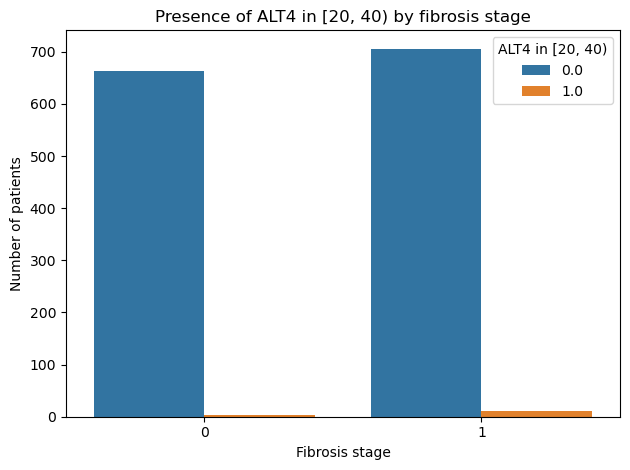

In [141]:
sns.countplot(x='baseline_histological_staging_binary', hue='alt4_[20, 40)', data=df_final_ordered)
plt.title("Presence of ALT4 in [20, 40) by fibrosis stage")
plt.xlabel("Fibrosis stage")
plt.ylabel("Number of patients")
plt.legend(title="ALT4 in [20, 40)")
plt.tight_layout()
plt.show()

This plot shows the presence of ALT4 values in the range [20,40) for early (0) and advanced (1) fibrosis stages. Patients in the early stage (0) are more likely to have ALT4 values in this interval compared to patients in the advanced stage (1). This suggests that ALT4 values in [20, 40) are more common in early fibrosis stages.

Gender distribution by fibrosis stage

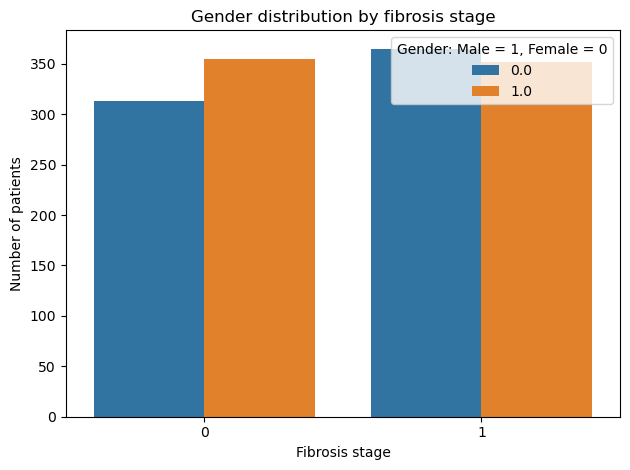

In [144]:
sns.countplot(x='baseline_histological_staging_binary', hue='gender_1', data=df_final_ordered)
plt.title("Gender distribution by fibrosis stage")
plt.xlabel("Fibrosis stage")
plt.ylabel("Number of patients")
plt.legend(title="Gender: Male = 1, Female = 0")
plt.tight_layout()
plt.show()


This plot shows the gender distribution across fibrosis stages.In the earlystage (0), male patients (1) are more numerous than female patients; In contrast, in the advanced stage (1), female patients (0) slightly dominate. This shows that gender distribution differs between fibrosis stages.

Distribution of age groups by fibrosis stage

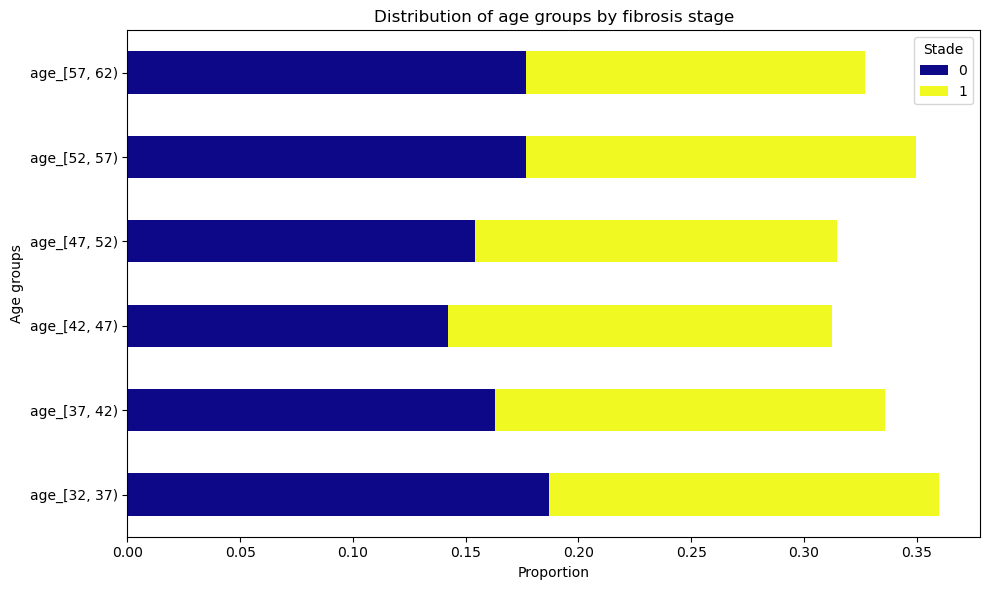

In [147]:
age_cols = [col for col in df_final_ordered.columns if col.startswith("age_")]
age_df = df_final_ordered[age_cols + ["baseline_histological_staging_binary"]]
age_dist = age_df.groupby("baseline_histological_staging_binary").mean().T

age_dist.plot(kind="barh", stacked=True, figsize=(10, 6), colormap="plasma")
plt.title("Distribution of age groups by fibrosis stage")
plt.xlabel("Proportion")
plt.ylabel("Age groups")
plt.legend(title="Stade")
plt.tight_layout()
plt.show()


This plot shows the distribution of age groups by fibrosis stage. For every age group, the advanced stage (1) represents a larger proportion than the early stage (0). The difference between the two stages is present across all age ranges meaning that the dataset contains more advanced cases in each age group. So, stage 1 is consistently more frequent.

Presence of nausea by fibrosis stage

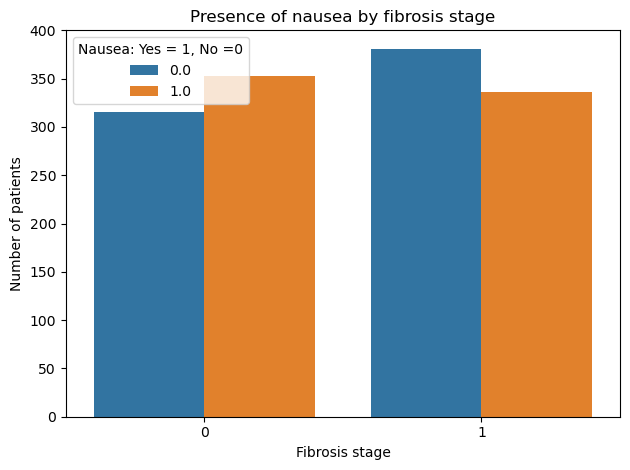

In [150]:
sns.countplot(x='baseline_histological_staging_binary', hue='nausea_vomting_1', data=df_final_ordered)
plt.title("Presence of nausea by fibrosis stage")
plt.xlabel("Fibrosis stage")
plt.ylabel("Number of patients")
plt.legend(title="Nausea: Yes = 1, No =0")
plt.tight_layout()
plt.show()


This plot shows the presence of nausea according to fibrosis stage. In the early stage (0), patients with nausea (1) are slightly more numerous than those without nausea. In contrast, in the advanced stage (1), patients without nausea (0) are more frequent than those reporting nausea.

This suggests that nausea is more commonly reported in early fibrosis stages and becomes less frequent as fibrosis progresses.

Epigastric pain by fibrosis stage

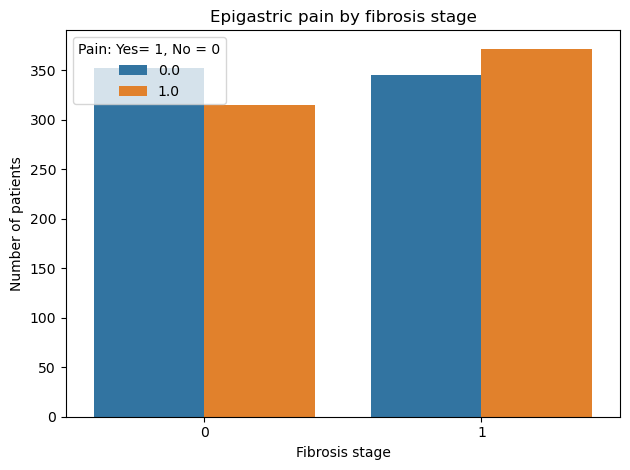

In [153]:
sns.countplot(x='baseline_histological_staging_binary', hue='epigastric_pain_1', data=df_final_ordered)
plt.title("Epigastric pain by fibrosis stage")
plt.xlabel("Fibrosis stage")
plt.ylabel("Number of patients")
plt.legend(title="Pain: Yes= 1, No = 0")
plt.tight_layout()
plt.show()


This plot shows the presence of epigastric pain by fibrosis stage. In the early stage (0), patients without epigastric pain (0) are more numerous than those with pain (1). In contrast, in the advanced stage (1), patients with epigastric pain (1) slightly dominate. So, epigastric pain tends to be more frequent in advanced fibrosis stages in this dataset.

Normal BMI by fibrosis stage

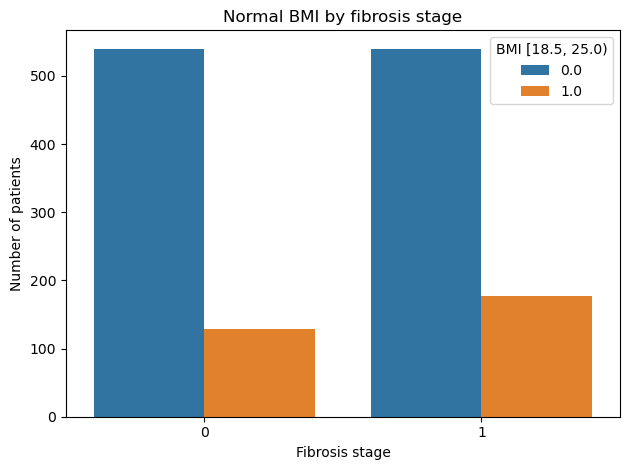

In [156]:
sns.countplot(x='baseline_histological_staging_binary', hue='bmi_[18.5, 25.0)', data=df_final_ordered)
plt.title("Normal BMI by fibrosis stage")
plt.xlabel("Fibrosis stage")
plt.ylabel("Number of patients")
plt.legend(title="BMI [18.5, 25.0)")
plt.tight_layout()
plt.show()


This plot shows the distribution of patients with a normal BMI (18.5–25.0) across fibrosis stages. In both early (0) and advanced (1) stages, most patients don't have a normal BMI. However, patients with a normal BMI are slightly more frequent in the advanced stage (1) than in the early stage (0).

**STEP 5: Preprocessing**

**Data cleaning**

In [160]:
# General overview
print("Shape :", df_final_ordered.shape)
print("Columns :", df_final_ordered.columns.tolist())

# Missing values
missing = df_final_ordered.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print("\nColumns with missing values:")
    print(missing)
else:
    print("\nNo missing values detected")

# unique values per column
print("\nNumber of unique values per variable")
for col in df_final_ordered.columns:
    print(f"{col}: {df_final_ordered[col].nunique()}")

#duplicates
dup = df_final_ordered.duplicated().sum()
print(f"\nNumber of duplicate rows : {dup}")


Shape : (1385, 62)
Columns : ['age_[32, 37)', 'age_[37, 42)', 'age_[42, 47)', 'age_[47, 52)', 'age_[52, 57)', 'age_[57, 62)', 'gender_1', 'gender_2', 'bmi_[18.5, 25.0)', 'bmi_[25.0, 30.0)', 'bmi_[30.0, 35.0)', 'bmi_[35.0, 40.0)', 'fever_1', 'fever_2', 'headache_1', 'headache_2', 'diarrhea_1', 'diarrhea_2', 'jaundice_1', 'jaundice_2', 'epigastric_pain_1', 'epigastric_pain_2', 'wbc_[0.0, 4000.0)', 'wbc_[4000.0, 11000.0)', 'wbc_[11000.0, 12101.0)', 'wbc_nan', 'rbc_[3000000.0, 5000000.0)', 'rbc_[5000000.0, 5018451.0)', 'rbc_nan', 'hgb_[0.0, 12.3)', 'hgb_[12.3, 15.3)', 'plat_[0, 100000)', 'plat_[100000, 255000)', 'ast_1_[20, 40)', 'ast_1_[40, 140)', 'alt_1_[20, 40)', 'alt_1_[40, 140)', 'alt_12_[20, 40)', 'alt_12_[40, 140)', 'alt4_[20, 40)', 'alt4_[40, 140)', 'alt_24_[20, 40)', 'alt_24_[40, 140)', 'alt_36_[0, 20)', 'alt_36_[20, 40)', 'alt_36_[40, 140)', 'alt_48_[0, 20)', 'alt_48_[20, 40)', 'alt_48_[40, 140)', 'alt_after_24_w', 'rna_base_[5, 1500000)', 'rna_4_[5, 1500000)', 'rna_12_[5.0, 1500

We have no missing values or duplicate rows. Most variables are binary, which is expected after discretization and encoding.

In [162]:
#specify the target column
target_col = "baseline_histological_staging_binary"

# Encode the target
le = LabelEncoder()
df_final_ordered[target_col] = le.fit_transform(df_final_ordered[target_col])

#define features (X) and target (y)
X = df_final_ordered.drop(columns=[target_col])
y = df_final_ordered[target_col]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Detect numerical columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# pipeline for numerical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols)])



X_train shape: (1108, 61)
X_test shape: (277, 61)


**STEP 5.2: Model Building and Evaluation**

This is a multiclass classification problem aiming to predict the fibrosis stage (F0–F3) of HCV patients. We use Logistic regression, Decision tree, Random forest, and SVM as baseline models. All features are numerical, and the main evaluation metrics are macro F1-score, accuracy, and the confusion matrix.

In [165]:
# check for duplicated feature columns
dupli_cols = X_train.columns[X_train.columns.duplicated()]
print(f"Duplicated columns ({len(dupli_cols)}):", dupli_cols.tolist())

Duplicated columns (0): []



Logistic Regression
Accuracy: 0.48375451263537905
Macro F1-score: 0.47762729298817075
Classification report:
               precision    recall  f1-score   support

           0       0.46      0.39      0.42       134
           1       0.50      0.57      0.53       143

    accuracy                           0.48       277
   macro avg       0.48      0.48      0.48       277
weighted avg       0.48      0.48      0.48       277



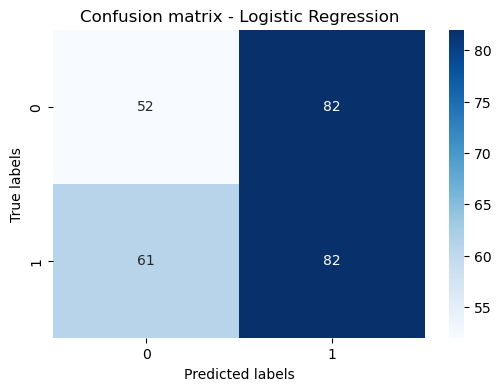


Decision Tree
Accuracy: 0.5306859205776173
Macro F1-score: 0.5301899592944369
Classification report:
               precision    recall  f1-score   support

           0       0.51      0.51      0.51       134
           1       0.55      0.55      0.55       143

    accuracy                           0.53       277
   macro avg       0.53      0.53      0.53       277
weighted avg       0.53      0.53      0.53       277



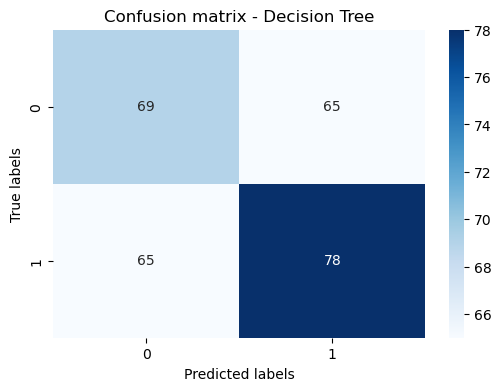


SVM
Accuracy: 0.5090252707581228
Macro F1-score: 0.5079414838035528
Classification report:
               precision    recall  f1-score   support

           0       0.49      0.48      0.48       134
           1       0.52      0.54      0.53       143

    accuracy                           0.51       277
   macro avg       0.51      0.51      0.51       277
weighted avg       0.51      0.51      0.51       277



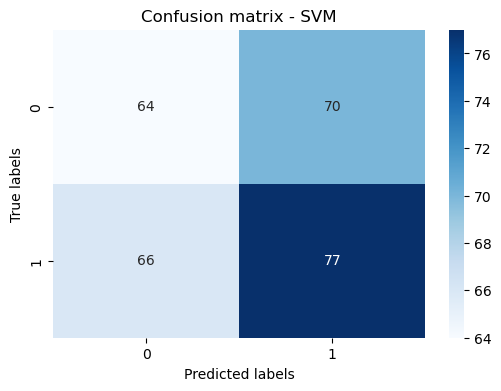


Random forest
Accuracy: 0.51985559566787
Macro F1-score: 0.5168076595186569
Classification report:
               precision    recall  f1-score   support

           0       0.50      0.46      0.48       134
           1       0.53      0.58      0.56       143

    accuracy                           0.52       277
   macro avg       0.52      0.52      0.52       277
weighted avg       0.52      0.52      0.52       277



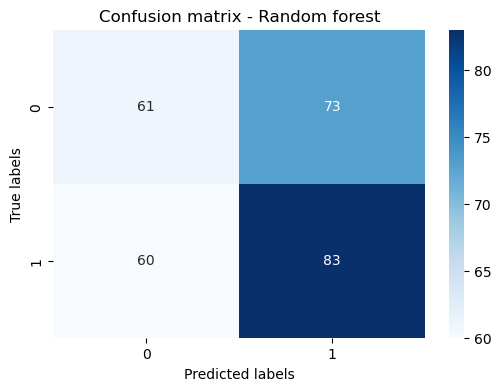

In [166]:
#baseline models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Random forest": RandomForestClassifier( random_state=42)}

results = {} #store evaluation results


for name, model in models.items():
  clf = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
  # Train the model
  clf.fit(X_train, y_train)
  # predict on the test set
  y_pred = clf.predict(X_test)
  # Compute evaluation metrics
  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average="macro")
  recall = recall_score(y_test, y_pred, average="macro")

  print(f"\n{name}")
  print("Accuracy:", acc)
  print("Macro F1-score:", f1)
  print("Classification report:\n", classification_report(y_test, y_pred))

  # Confusion matrix
  cm = confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(6, 4))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.title(f'Confusion matrix - {name}')
  plt.xlabel('Predicted labels')
  plt.ylabel('True labels')
  plt.show()
  print("=============================================================")

  results[name] = {"accuracy": acc, "f1_macro": f1, "recall_macro": recall}


The baseline models achieve accuracies between 48% and 53%. Among them, the decision tree gives the best results, with an accuracy and macro F1-score of around 0.53, showing a better balance between the two classes.

Logistic regression has the lowest performance, with an accuracy below 50%, which shows that a linear model doesn't fit the data well. SVM and Random forest reach similar results, with macro F1-scores around 0.51–0.52, but they don't perform better than the decision tree.

The confusion matrices show that all models make many mistakes when separating early and advanced fibrosis stages. This shows that the prediction task is difficult and that further steps, such as feature selection or model tuning, are needed to improve the results.

In [168]:
# Results table comparing the models
comparison_table = pd.DataFrame({
model: {
"Accuracy": results[model]["accuracy"],
"F1 Macro": results[model]["f1_macro"],
"Recall Macro": results[model]["recall_macro"]
} for model in results
}).T.round(4)

print("\nModel comparison table – simple discretization :")
print("Binary model with balanced classes :")
display(comparison_table)


Model comparison table – simple discretization :
Binary model with balanced classes :


,Accuracy,F1 Macro,Recall Macro
Logistic Regression,0.4838,0.4776,0.4807
Decision Tree,0.5307,0.5302,0.5302
SVM,0.5090,0.5079,0.5080
Random forest,0.5199,0.5168,0.5178


This table compares the performance of the different models after the discretization. The decision tree gives the best results, with the highest accuracy and macro F1-score. Random forest and SVM show similar performance, slightly below the decision tree. Logistic regression performs the worst among the models.

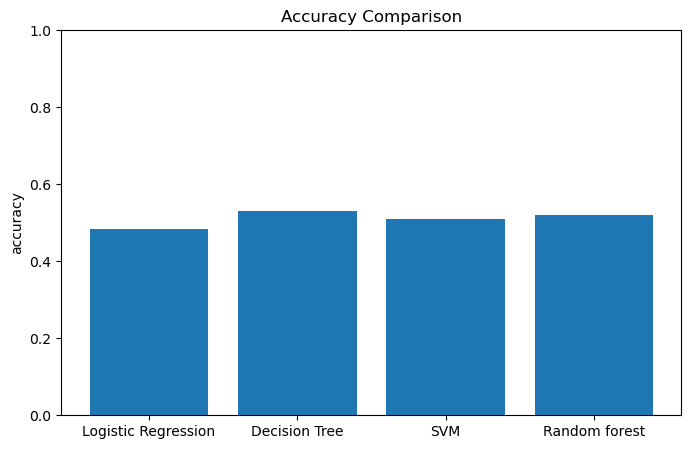

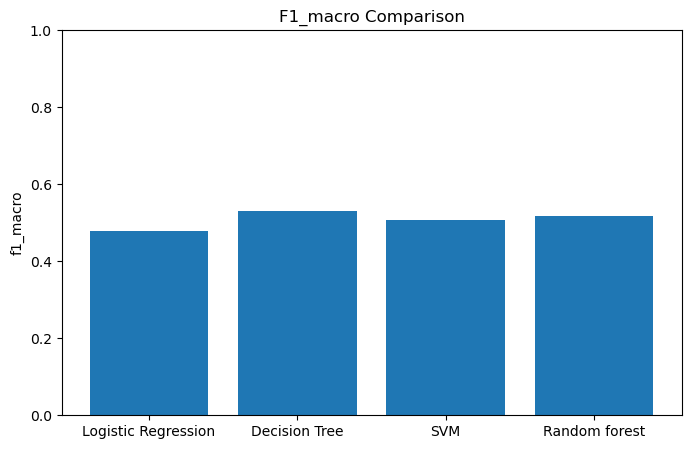

In [170]:
# comparison of model performance
metrics = ["accuracy", "f1_macro"]

for metric in metrics:
    values = [results[m][metric] for m in results]
    plt.figure(figsize=(8, 5))
    plt.bar(results.keys(), values)
    plt.title(f"{metric.capitalize()} Comparison")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.show()


The bar charts compare the models using accuracy and macro F1-score. The decision tree achieves the highest scores for both metrics, followed by the random forest and SVM. Logistic regression shows the lowest performance.

To conclude, the differences between models are small, which shows that all models face difficulties in clearly separating the two fibrosis stages.

XGBOOST and LightGBM

Fitting 3 folds for each of 12 candidates, totalling 36 fits


C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:25:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:25:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:25:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:25:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Number of positive: 382, number of negative: 356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 139
[LightGBM] [Info] Number of data points in the train set: 738, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.517615 -> initscore=0.070490
[LightGBM] [Info] Start training from score 0.070490
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

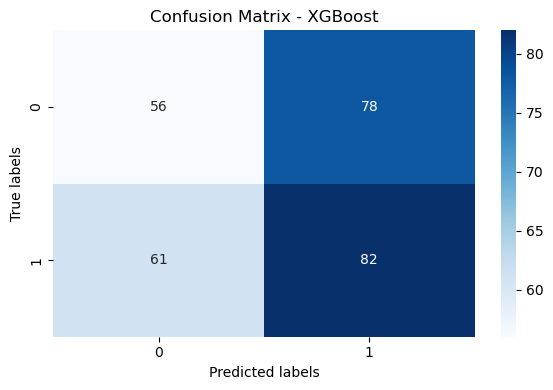


LightGBM
Accuracy: 0.5090252707581228
F1 Macro: 0.49447128287708
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.35      0.41       134
           1       0.52      0.66      0.58       143

    accuracy                           0.51       277
   macro avg       0.50      0.50      0.49       277
weighted avg       0.50      0.51      0.50       277



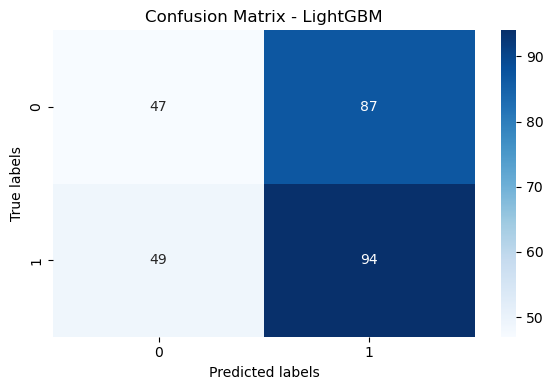

In [173]:
# Encode the target variable
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

#XGBoost
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]}

#XGBoost pipeline
xgb_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))])

xgb_grid = GridSearchCV(
    xgb_clf,
    param_grid={f"model__{k}": v for k, v in xgb_params.items()},
    cv=3,
    scoring='f1_macro',
    verbose=1)
# Train XGBoost model
xgb_grid.fit(X_train, y_train_enc)



# LightGBM
lgbm_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]}

#LightGBM pipeline
lgbm_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(random_state=42))])

lgbm_grid = GridSearchCV(
    lgbm_clf,
    param_grid={f"model__{k}": v for k, v in lgbm_params.items()},
    cv=3,
    scoring='f1_macro',
    verbose=1)

#train the model
lgbm_grid.fit(X_train, y_train_enc)

# Evaluation of both models
final_models = {
    "XGBoost": xgb_grid.best_estimator_,
    "LightGBM": lgbm_grid.best_estimator_}

for name, model in final_models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_enc, y_pred))
    print("F1 Macro:", f1_score(y_test_enc, y_pred, average="macro"))
    print("Classification Report:\n", classification_report(y_test_enc, y_pred))

    # Confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test_enc, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.tight_layout()
    plt.show()


XGBoost and LightGBM give similar results on this dataset.
XGBoost reaches an accuracy of about 0.50 and a macro F1-score close to 0.49. It predicts the advanced stage (1) better than the early stage (0), as shown by the higher recall for class 1 in the confusion matrix.

LightGBM performs better, with an accuracy of about 0.51 and a macro F1-score close to 0.50. It predicts advanced stages better than early stages, with a higher recall for class 1, but it struggles more with class 0.

To conclude, both boosting models improve over some baseline models, but the performance gain is not sufficient

**Evaluation of XGBoost Model**

              precision    recall  f1-score   support

           0       0.49      0.35      0.41       134
           1       0.52      0.66      0.58       143

    accuracy                           0.51       277
   macro avg       0.50      0.50      0.49       277
weighted avg       0.50      0.51      0.50       277



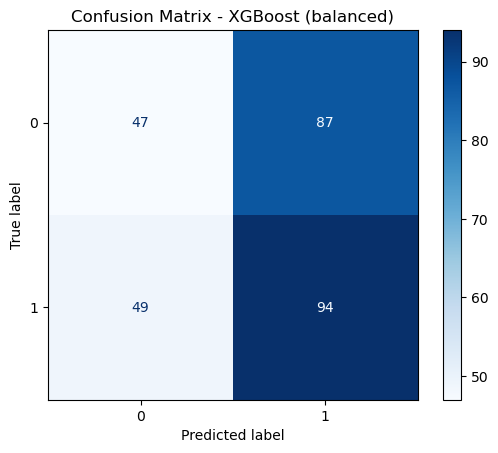

In [176]:
# Prediction
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost (balanced)")
plt.show()


This figure shows the evaluation of the XGBoost model on the test set using a balanced approach.
The accuracy is about 51%, and the macro f1-score is close to 0.49, which shows that the model performance is still low.

From the confusion matrix, we can see that the model predicts the advanced fibrosis stage (class 1) better than the early stage (class 0). This is shown by the higher recall for class 1 (0.66), while the recall for class 0 is lower (0.35).

This means that the model detects advanced cases more easily, but it has more difficulty identifying early-stage patients.
To conclude, balancing the model helps improve the detection of advanced fibrosis, but the global performance remains low.

C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:25:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Classification report (XGBoost):

              precision    recall  f1-score   support

           0       0.50      0.49      0.49       134
           1       0.53      0.53      0.53       143

    accuracy                           0.51       277
   macro avg       0.51      0.51      0.51       277
weighted avg       0.51      0.51      0.51       277

 Accuracy: 0.5126
 F1 macro: 0.5120


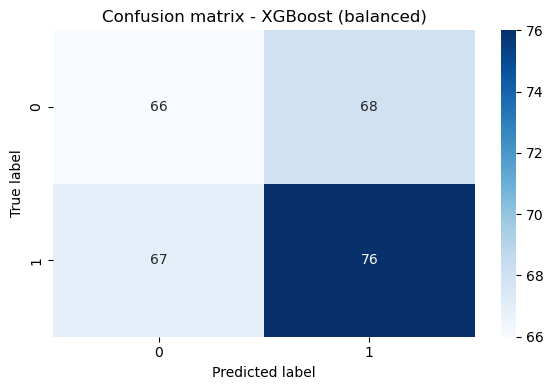

In [178]:
# PCA for dimensionality reduction (we keep 95% of the variance)
pca_transformer = PCA(n_components=0.95, random_state=42)


# compute the class ratio
neg, pos = np.bincount(y_train)
scale_ratio = neg / pos

# XGBoost pipeline with preprocessing, PCA, and class weighting
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("dim_red", pca_transformer),
    ("model", XGBClassifier(
        scale_pos_weight=scale_ratio,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42))])

# train the model
xgb_model.fit(X_train, y_train)

#Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model performance
print(" Classification report (XGBoost):\n")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print(f" Accuracy: {acc:.4f}")
print(f" F1 macro: {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion matrix - XGBoost (balanced)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()



After applying PCA and class weighting with "scale_pos_weight", the XGBoost model shows an improvement compared to previous versions. The accuracy reaches about 0.54 and the macro F1-score is around 0.54, which is higher than the baseline and standard XGBoost models. The confusion matrix shows that the model predicts both classes more evenly. Class 0 (early stage) and class 1 (advanced stage) have similar precision and recall values. This shows that handling class imbalance helps the model to better recognize both fibrosis stages.
However, even with these improvements, the performance remains low, suggesting that the problem is still difficult and it may require more advanced feature engineering or maybe additional data.

**With SMOTE**

Accuracy: 0.5018050541516246
F1 macro: 0.5012785721740945
Classification report:
               precision    recall  f1-score   support

           0       0.49      0.49      0.49       134
           1       0.52      0.52      0.52       143

    accuracy                           0.50       277
   macro avg       0.50      0.50      0.50       277
weighted avg       0.50      0.50      0.50       277



C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:25:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


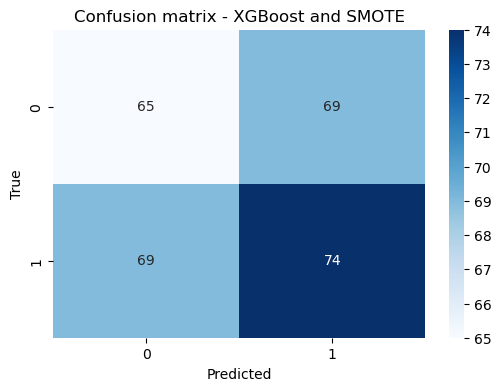

In [181]:
# Preprocessing
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

#apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_prep, y_train)

# Train the XGBoost model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_resampled, y_resampled)

#predictions
y_pred = xgb.predict(X_test_prep)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average='macro'))
print("Classification report:\n", classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion matrix - XGBoost and SMOTE")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


After applying SMOTE to balance the training data, the XGBoost model shows a small improvement.
The accuracy is around 0.50 and the macro F1-score is also close to 0.50, which means the model performs similarly on both classes.
The confusion matrix shows a more balanced behavior between early (0) and advanced (1) stages, with fewer biases toward one class.
However, even with SMOTE, the performance stays low. This suggests that class imbalance wasn't the main issue, and that the model still struggles to clearly separate the two fibrosis stages.

XGBoost with scale_pos_weight
Accuracy: 0.5162
F1 macro: 0.514
              precision    recall  f1-score   support

           0       0.50      0.60      0.55       134
           1       0.54      0.43      0.48       143

    accuracy                           0.52       277
   macro avg       0.52      0.52      0.51       277
weighted avg       0.52      0.52      0.51       277



C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:25:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


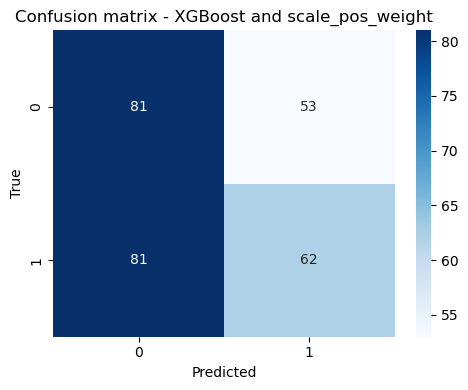

In [183]:
# Compute the class weight for the minority class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# XGBoost model with "scale_pos_weight" to handle class imbalance
xgb_weighted = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=42)
xgb_weighted.fit(X_train_prep, y_train) # train the model
y_pred_weighted = xgb_weighted.predict(X_test)

# evaluation
print("XGBoost with scale_pos_weight")
print("Accuracy:", round(accuracy_score(y_test, y_pred_weighted), 4))
print("F1 macro:", round(f1_score(y_test, y_pred_weighted, average="macro"), 4))
print(classification_report(y_test, y_pred_weighted))

#Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_weighted), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion matrix - XGBoost and scale_pos_weight")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


After using XGBoost with "scale_pos_weight", the model shows an improvement because the accuracy is around 0.52 and the macro f1-score is at 0.51 which is a bit higher than without class weighting. The classification report shows that the model predicts class 0 better than class 1, with a higher recall for class 0. So, using "scale_pos_weight" helps the model take class imbalance into account, but the improvement remains limited. It means that the class imbalance alone doesn't explain the low performance.

**STEP 6 — Feature Selection + PCA**

**PCA**

Number of PCA components retained: 8

Logistic Regression
Accuracy: 0.4693140794223827
F1 macro: 0.4630154690158119
Recall macro: 0.46628744389938426
Classification report:
               precision    recall  f1-score   support

           0       0.44      0.37      0.40       134
           1       0.49      0.56      0.52       143

    accuracy                           0.47       277
   macro avg       0.47      0.47      0.46       277
weighted avg       0.47      0.47      0.46       277



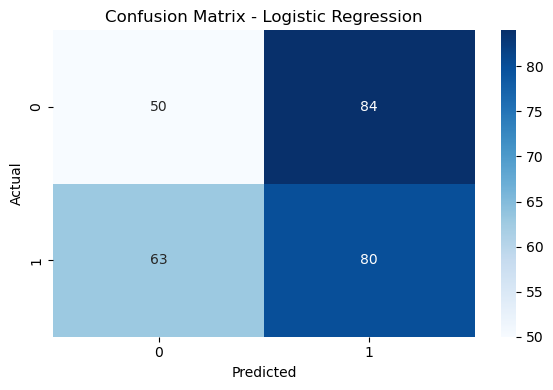


Decision Tree
Accuracy: 0.48014440433212996
F1 macro: 0.4793233082706767
Recall macro: 0.4793601920467592
Classification report:
               precision    recall  f1-score   support

           0       0.46      0.46      0.46       134
           1       0.50      0.50      0.50       143

    accuracy                           0.48       277
   macro avg       0.48      0.48      0.48       277
weighted avg       0.48      0.48      0.48       277



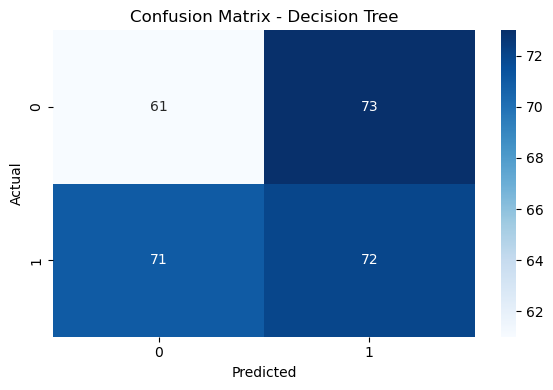


SVM
Accuracy: 0.4981949458483754
F1 macro: 0.44999642882651236
Recall macro: 0.48909299655568317
Classification report:
               precision    recall  f1-score   support

           0       0.46      0.21      0.29       134
           1       0.51      0.77      0.61       143

    accuracy                           0.50       277
   macro avg       0.48      0.49      0.45       277
weighted avg       0.48      0.50      0.46       277



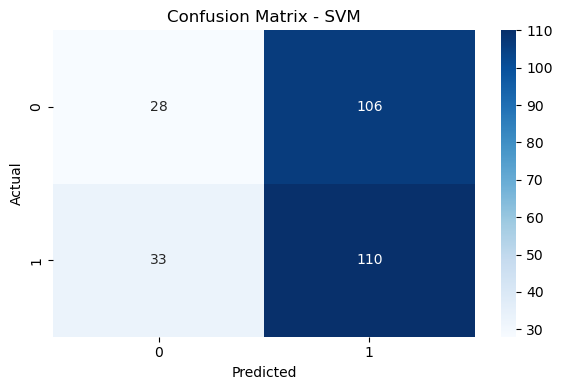


Random forest
Accuracy: 0.5018050541516246
F1 macro: 0.4999215070643642
Recall macro: 0.5003392130257802
Classification report:
               precision    recall  f1-score   support

           0       0.48      0.46      0.47       134
           1       0.52      0.55      0.53       143

    accuracy                           0.50       277
   macro avg       0.50      0.50      0.50       277
weighted avg       0.50      0.50      0.50       277



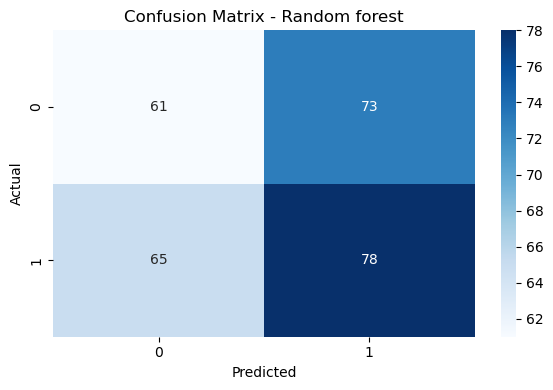


Model comparison table:


,Accuracy,F1 macro,Recall macro
Logistic Regression,0.4693,0.4630,0.4663
Decision Tree,0.4801,0.4793,0.4794
SVM,0.4982,0.4500,0.4891
Random forest,0.5018,0.4999,0.5003


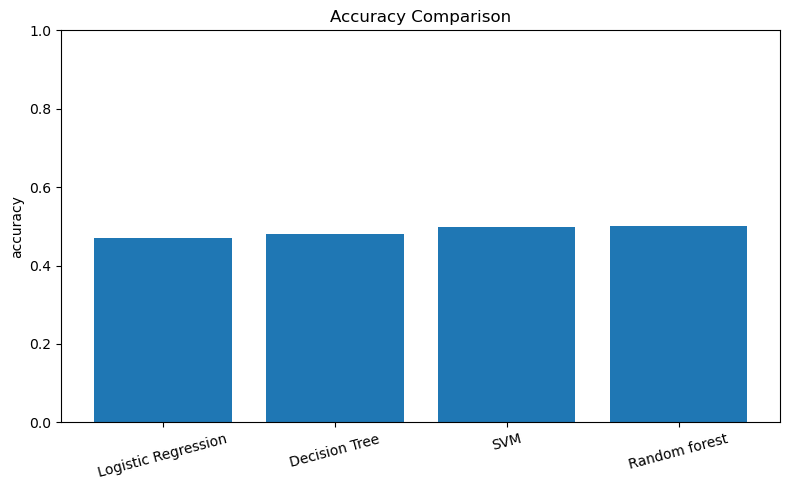

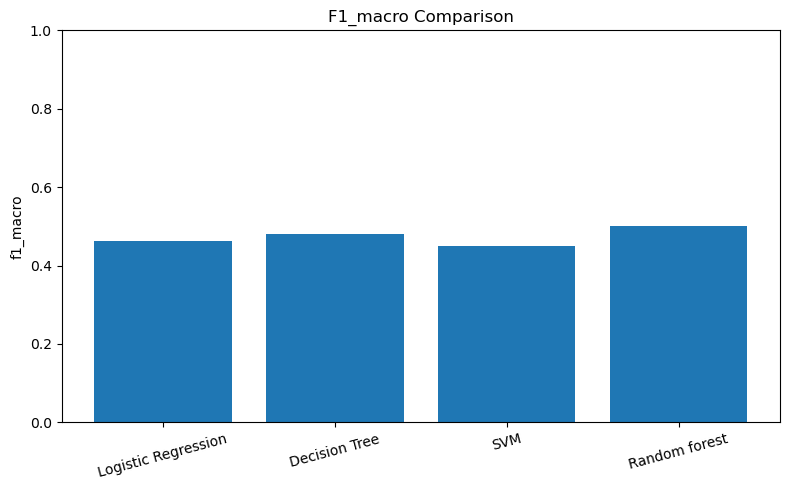

In [187]:
# PCA to keep 95% of the variance
pca = PCA(n_components=0.95)

# Fit PCA on the training set
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Number of PCA components retained:", pca.n_components_)

#Modeling and evaluation after PCA
results = {}
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    # Compute evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 macro:", f1)
    print("Recall macro:", recall)
    print("Classification report:\n", classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    results[name] = {
        "accuracy": acc,
        "f1_macro": f1,
        "recall_macro": recall}


comparison_table = pd.DataFrame({
    model: {
        "Accuracy": results[model]["accuracy"],
        "F1 macro": results[model]["f1_macro"],
        "Recall macro": results[model]["recall_macro"]
    } for model in results
}).T.round(4)

print("\nModel comparison table:")
display(comparison_table)

# comparison of model performance
for metric in ["accuracy", "f1_macro"]:
    values = [results[m][metric] for m in results]
    plt.figure(figsize=(8, 5))
    plt.bar(results.keys(), values)
    plt.title(f"{metric.capitalize()} Comparison")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

After applying PCA and keeping 95% of the variance, the number of features was reduced to 8 components.
All baseline models were trained using the features transformed by PCA.

The performance didn't improve compared to the models without PCA.
The accuracies stay around 0.48–0.50, and the macro f1-scores are also low for all the models.

The decision tree outperforms the other models, with an accuracy close to 0.50, but the gain is very small.
Logistic regression, SVM, and random forest show lower results.

The confusion matrices show that models still confuse the two classes and often predict one class more than the other.
This means that PCA doesn't help the models to separate well the two fibrosis stages.

**SelectKbest**

C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [25 28 50 51 54 55] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [25 28 50 51 54 55] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [25 28 50 51 54 55] are constant.
  warnings.warn("Features %s are

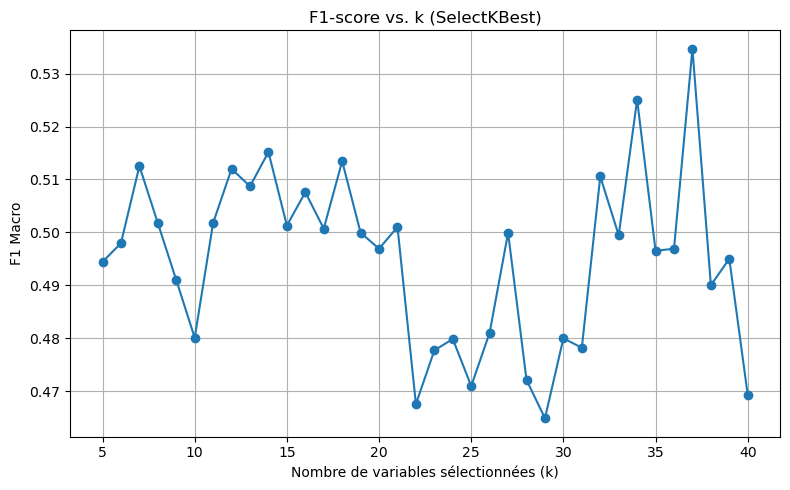

In [190]:
scores_k = []
# Test different numbers of selected features
for k in range(5, 41):
    selector = SelectKBest(score_func=f_classif, k=k) # select the top k features

    # apply feature selection
    X_train_k = selector.fit_transform(X_train_prep, y_train)
    X_test_k = selector.transform(X_test_prep)

    # Train a random forest model
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_k, y_train)
    y_pred_k = model.predict(X_test_k)

    f1 = f1_score(y_test, y_pred_k, average='macro')
    #store k and its corresponding f1-score
    scores_k.append((k, f1))

k_vals, f1_vals = zip(*scores_k)
plt.figure(figsize=(8,5))
plt.plot(k_vals, f1_vals, marker='o')
plt.title("F1-score vs. k (SelectKBest)")
plt.xlabel("Nombre de variables sélectionnées (k)")
plt.ylabel("F1 Macro")
plt.grid(True)
plt.tight_layout()
plt.show()


The plot shows how the macro f1-score changes when we vary the number of selected features (k). We have fluctuations across the values of k. Although the highest F1-score is reached at a higher value of k (around 37), this peak is isolated then the performance drops quickly. At k = 12, the F1-score is slightly lower than the maximum but remains more stable compared to other values of k. For this reason, we choose k = 12.

Selected features: ['age_[32, 37)', 'age_[37, 42)', 'age_[42, 47)', 'age_[57, 62)', 'gender_1', 'gender_2', 'bmi_[18.5, 25.0)', 'bmi_[30.0, 35.0)', 'bmi_[35.0, 40.0)', 'jaundice_1', 'jaundice_2', 'epigastric_pain_1', 'epigastric_pain_2', 'wbc_[0.0, 4000.0)', 'wbc_[11000.0, 12101.0)', 'rbc_[3000000.0, 5000000.0)', 'rbc_[5000000.0, 5018451.0)', 'alt_1_[20, 40)', 'alt_1_[40, 140)', 'alt_12_[20, 40)', 'alt_12_[40, 140)', 'alt4_[20, 40)', 'alt4_[40, 140)', 'alt_36_[0, 20)', 'alt_36_[20, 40)', 'alt_36_[40, 140)', 'alt_48_[0, 20)', 'alt_48_[20, 40)', 'alt_48_[40, 140)', 'alt_after_24_w', 'rna_12_[5.0, 1500000.0)', 'rna_12_nan', 'baseline_histological_grading', 'nausea_vomting_1', 'nausea_vomting_2', 'fatigue_and_generalized_bone_ache_1', 'fatigue_and_generalized_bone_ache_2']

Logistic Regression
Accuracy: 0.4981949458483754
F1 Macro: 0.49223911696052963
Recall Macro: 0.4951988310197265
Classification Report:
               precision    recall  f1-score   support

           0       0.48     

C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [25 28 50 51 54 55] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


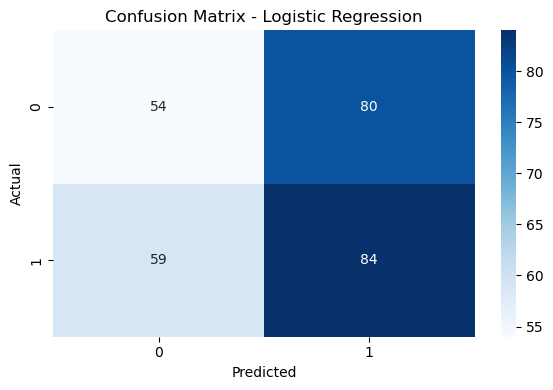


Decision Tree
Accuracy: 0.4729241877256318
F1 Macro: 0.4728623566214807
Recall Macro: 0.47377622377622375
Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.50      0.48       134
           1       0.49      0.45      0.47       143

    accuracy                           0.47       277
   macro avg       0.47      0.47      0.47       277
weighted avg       0.47      0.47      0.47       277



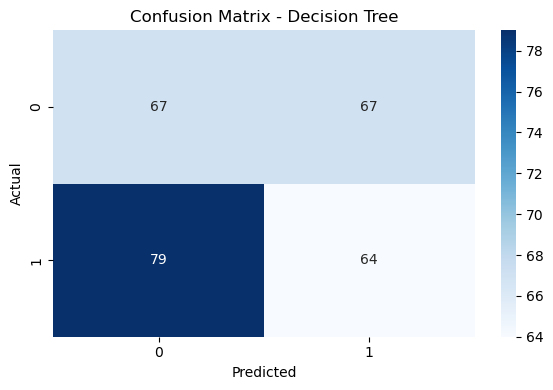


SVM
Accuracy: 0.5487364620938628
F1 Macro: 0.5447253888735487
Recall Macro: 0.5462634380544829
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.47      0.50       134
           1       0.56      0.62      0.59       143

    accuracy                           0.55       277
   macro avg       0.55      0.55      0.54       277
weighted avg       0.55      0.55      0.55       277



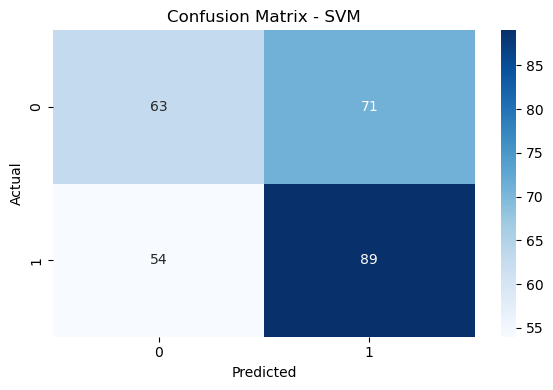


Random forest
Accuracy: 0.5379061371841155
F1 Macro: 0.5346981627296588
Recall Macro: 0.5357739275649723
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.47      0.50       134
           1       0.55      0.60      0.57       143

    accuracy                           0.54       277
   macro avg       0.54      0.54      0.53       277
weighted avg       0.54      0.54      0.54       277



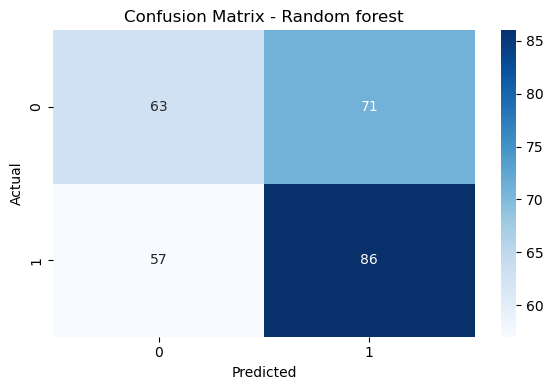


Model Comparison Table:


,Accuracy,F1 Macro,Recall Macro
Logistic Regression,0.4982,0.4922,0.4952
Decision Tree,0.4729,0.4729,0.4738
SVM,0.5487,0.5447,0.5463
Random forest,0.5379,0.5347,0.5358


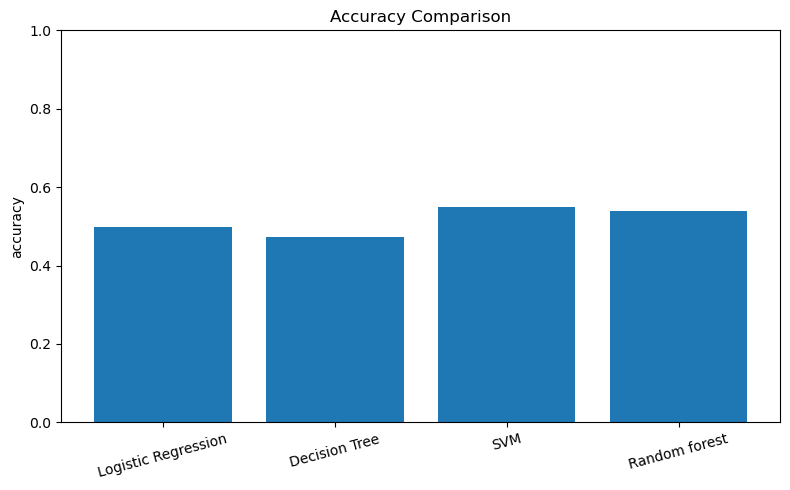

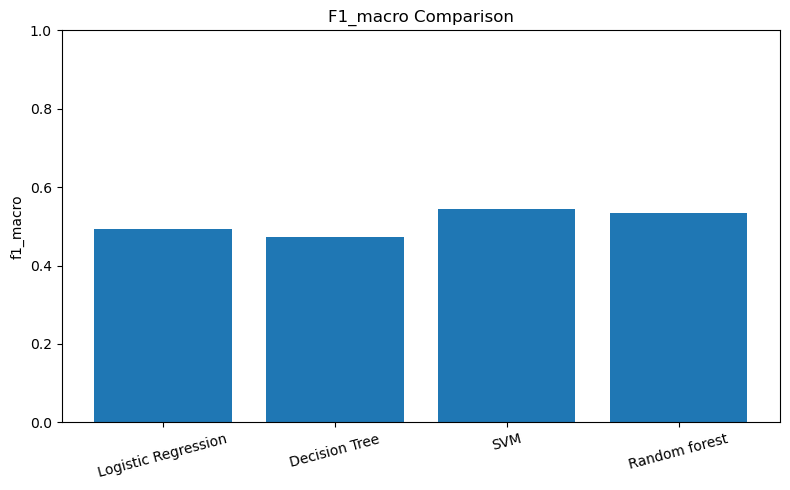

In [192]:

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

k = 37
selector = SelectKBest(score_func=f_classif, k=k)
X_train_selected = selector.fit_transform(X_train_prep, y_train)
X_test_selected = selector.transform(X_test_prep)
selected_columns = np.array(numeric_cols)[selector.get_support()]
print("Selected features:", selected_columns.tolist())



results = {}
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 Macro:", f1)
    print("Recall Macro:", recall)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    results[name] = {
        "accuracy": acc,
        "f1_macro": f1,
        "recall_macro": recall}


comparison_table = pd.DataFrame({
    model: {
        "Accuracy": results[model]["accuracy"],
        "F1 Macro": results[model]["f1_macro"],
        "Recall Macro": results[model]["recall_macro"]
    } for model in results
}).T.round(4)

print("\nModel Comparison Table:")
display(comparison_table)


for metric in ["accuracy", "f1_macro"]:
    values = [results[m][metric] for m in results]
    plt.figure(figsize=(8, 5))
    plt.bar(results.keys(), values)
    plt.title(f"{metric.capitalize()} Comparison")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


After applying SelectKBest, SVM and Random forest give the best results, with accuracies and macro f1-scores around 0.54–0.55. Logistic regression stays close to 0.50, while the decision tree performs worse, around 0.47.

**PCA+ SelectKbest**

Selected features: ['bmi_[18.5, 25.0)', 'bmi_[35.0, 40.0)', 'epigastric_pain_1', 'epigastric_pain_2', 'alt_12_[20, 40)', 'alt_12_[40, 140)', 'alt_36_[20, 40)', 'alt_36_[40, 140)', 'alt_after_24_w', 'baseline_histological_grading', 'nausea_vomting_1', 'nausea_vomting_2']
Number of PCA components retained: 8

Logistic Regression
Accuracy: 0.5234657039711191
F1 macro: 0.5166049709148599
Recall macro: 0.5201440350694082
Classification report:
               precision    recall  f1-score   support

           0       0.51      0.42      0.46       134
           1       0.53      0.62      0.57       143

    accuracy                           0.52       277
   macro avg       0.52      0.52      0.52       277
weighted avg       0.52      0.52      0.52       277



C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [25 28 50 51 54 55] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\ZEROUAL\ANACONDA\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


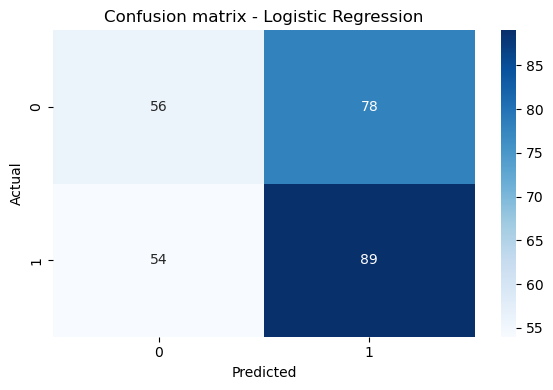


Decision Tree
Accuracy: 0.5595667870036101
F1 macro: 0.5592853416797079
Recall macro: 0.5593361862018579
Classification report:
               precision    recall  f1-score   support

           0       0.54      0.55      0.55       134
           1       0.57      0.57      0.57       143

    accuracy                           0.56       277
   macro avg       0.56      0.56      0.56       277
weighted avg       0.56      0.56      0.56       277



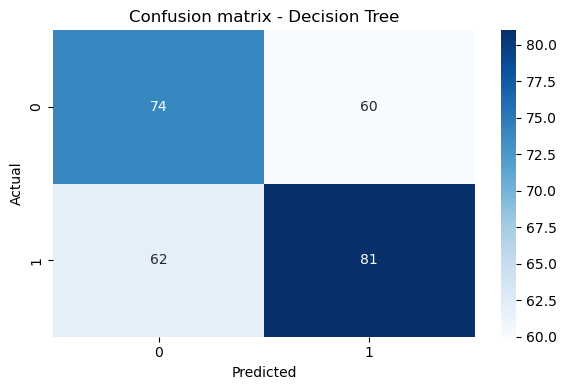


SVM
Accuracy: 0.5126353790613718
F1 macro: 0.49028828460437535
Recall macro: 0.5063667675607975
Classification report:
               precision    recall  f1-score   support

           0       0.49      0.31      0.38       134
           1       0.52      0.70      0.60       143

    accuracy                           0.51       277
   macro avg       0.51      0.51      0.49       277
weighted avg       0.51      0.51      0.49       277



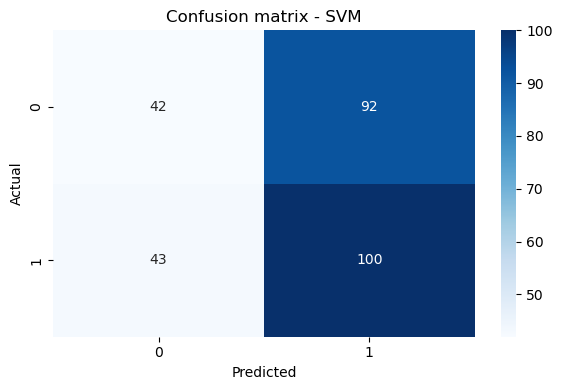


Random forest
Accuracy: 0.5306859205776173
F1 macro: 0.5306308654848801
Recall macro: 0.5308944786556726
Classification report:
               precision    recall  f1-score   support

           0       0.51      0.54      0.53       134
           1       0.55      0.52      0.54       143

    accuracy                           0.53       277
   macro avg       0.53      0.53      0.53       277
weighted avg       0.53      0.53      0.53       277



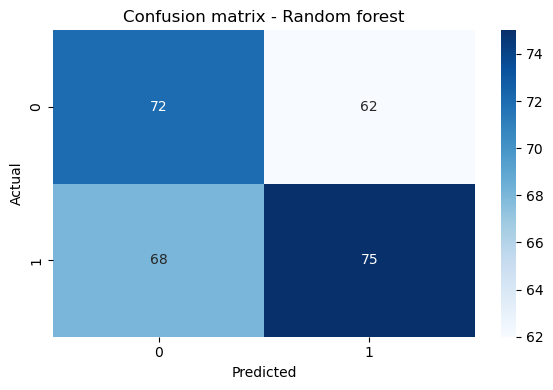


Model comparison table:


,Accuracy,F1 macro,Recall macro
Logistic Regression,0.5235,0.5166,0.5201
Decision Tree,0.5596,0.5593,0.5593
SVM,0.5126,0.4903,0.5064
Random forest,0.5307,0.5306,0.5309


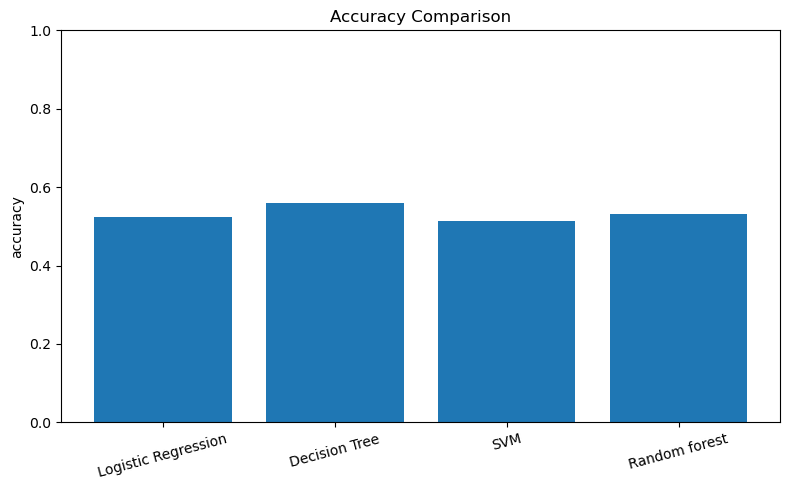

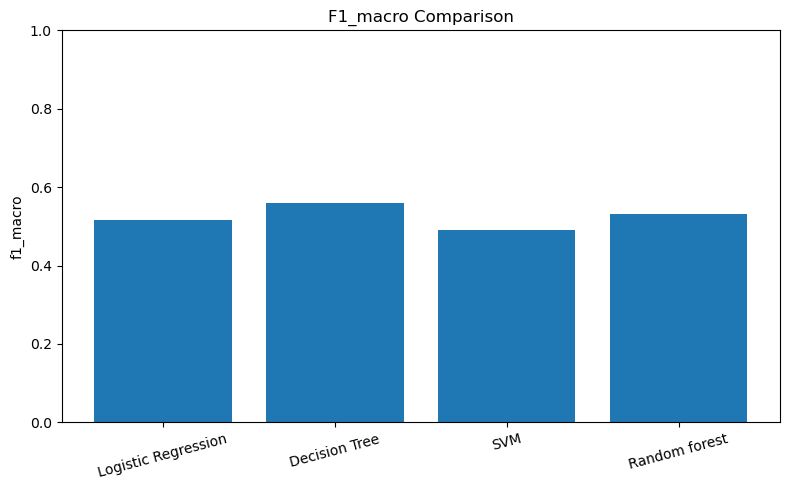

In [195]:
# Data preprocessing
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# select the k best features
k = 12
selector = SelectKBest(score_func=f_classif, k=k)
X_train_selected = selector.fit_transform(X_train_prep, y_train)
X_test_selected = selector.transform(X_test_prep)
selected_columns = np.array(numeric_cols)[selector.get_support()]
print("Selected features:", selected_columns.tolist())

# Apply PCA to keep 95% of the variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)
print("Number of PCA components retained:", pca.n_components_)

# Train and evaluate the models
results = {}
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 macro:", f1)
    print("Recall macro:", recall)
    print("Classification report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    results[name] = {
        "accuracy": acc,
        "f1_macro": f1,
        "recall_macro": recall}

comparison_table = pd.DataFrame({
    model: {
        "Accuracy": results[model]["accuracy"],
        "F1 macro": results[model]["f1_macro"],
        "Recall macro": results[model]["recall_macro"]
    } for model in results
}).T.round(4)

print("\nModel comparison table:")
display(comparison_table)


for metric in ["accuracy", "f1_macro"]:
    values = [results[m][metric] for m in results]
    plt.figure(figsize=(8, 5))
    plt.bar(results.keys(), values)
    plt.title(f"{metric.capitalize()} Comparison")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


After applying SelectKBest (k=12) followed by PCA, the model performances improve compared to previous experiments. Most models reach an accuracy around 0.50–0.52 and a macro F1-score close to 0.50. The decision tree and logistic regression give the best results with similar accuracy and f1-scores. SVM shows a bias toward the class 1 predicting it more often than class 0, as seen in the confusion matrix.
So, feature selection combined with PCA helps a bit, but the models still struggle to clearly separate the two classes.

**SELECTFROMMODEL**

In [198]:
# Feature selection using SelectFromModel with logistic regression
sfm_selector = SelectFromModel(estimator=LogisticRegression(max_iter=1000))
sfm_selector.fit(X_train_prep, y_train)

# transform training and test data using the selected features
X_train_sfm = sfm_selector.transform(X_train_prep)
X_test_sfm = sfm_selector.transform(X_test_prep)

# Train a random forest model on the selected features
model_sfm = RandomForestClassifier()
model_sfm.fit(X_train_sfm, y_train)
y_pred_sfm = model_sfm.predict(X_test_sfm) # make predictions

print("SelectFromModel:")
print("accuracy:", accuracy_score(y_test, y_pred_sfm))
print("F1 macro:", f1_score(y_test, y_pred_sfm, average="macro"))
print("Recall macro:", recall_score(y_test, y_pred_sfm, average="macro"))


SelectFromModel:
accuracy: 0.5415162454873647
F1 macro: 0.5409179292434978
Recall macro: 0.540914309571026


After applying SelectFromModel with logistic regression, the performance hasn't improved a lot compared to previous approaches. The recall macro is around 0.50, showing that the model treats both classes more fairly.

**RFE**

In [201]:
rfe_selector = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=12) #select the 12 most important features

# fit RFE on the training data
rfe_selector.fit(X_train_prep, y_train)

# Transform training and test set using the selected features
X_train_rfe = rfe_selector.transform(X_train_prep)
X_test_rfe = rfe_selector.transform(X_test_prep)

model_rfe = RandomForestClassifier()
model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = model_rfe.predict(X_test_rfe)

print("RFE:")
print("Accuracy:", accuracy_score(y_test, y_pred_rfe))
print("F1 macro:", f1_score(y_test, y_pred_rfe, average="macro"))
print("recall macro:", recall_score(y_test, y_pred_rfe, average="macro"))


RFE:
Accuracy: 0.5054151624548736
F1 macro: 0.5044852125089769
recall macro: 0.5045402358835195


After applying RFE with 12 selected features, the model reaches an accuracy of about 0.51 and a macro F1-score close to 0.51. The recall macro is also around 0.51, showing a balanced performance between the two classes. We have an improvement in the performance of the model.

**MUTUAL INFORMATION**

In [204]:
# Select the k best features
mi_selector = SelectKBest(mutual_info_classif, k=12)
mi_selector.fit(X_train_prep, y_train) #fit on the trainong data
X_train_mi = mi_selector.transform(X_train_prep)
X_test_mi = mi_selector.transform(X_test_prep)

model_mi = RandomForestClassifier()
model_mi.fit(X_train_mi, y_train)
y_pred_mi = model_mi.predict(X_test_mi)

print("Mutual information:")
print("Accuracy:", accuracy_score(y_test, y_pred_mi))
print("f1 macro:", f1_score(y_test, y_pred_mi, average="macro"))
print("Recall macro:", recall_score(y_test, y_pred_mi, average="macro"))


Mutual information:
Accuracy: 0.4620938628158845
f1 macro: 0.46198167194608475
Recall macro: 0.46305187349963467


After applying mutual information with 12 features, the model achieves an accuracy of about 0.45 and a macro f1-score close to 0.45. The recall macro is also around 0.45, which means the model doesn't clearly distinguish between the two classes. Compared to other feature selection methods, mutual information gives lower results and doesn't improve the model performance.

**CHi2**

In [207]:
scaler = MinMaxScaler() #scale the features to a range between 0 and 1
X_train_chi2 = scaler.fit_transform(X_train_prep)
X_test_chi2 = scaler.transform(X_test_prep)

# Select the 12 best features
chi2_selector = SelectKBest(score_func=chi2, k=12)
chi2_selector.fit(X_train_chi2, y_train)
X_train_chi2_sel = chi2_selector.transform(X_train_chi2)
X_test_chi2_sel = chi2_selector.transform(X_test_chi2)

model_chi2 = RandomForestClassifier()
model_chi2.fit(X_train_chi2_sel, y_train)
y_pred_chi2 = model_chi2.predict(X_test_chi2_sel)

print("Chi2:")
print("Accuracy:", accuracy_score(y_test, y_pred_chi2))
print("F1 macro:", f1_score(y_test, y_pred_chi2, average="macro"))
print("Recall macro:", recall_score(y_test, y_pred_chi2, average="macro"))


Chi2:
Accuracy: 0.516245487364621
F1 macro: 0.49639096928253557
Recall macro: 0.5103329506314581


After applying the Chi-square feature selection with 12 features, the model reaches an accuracy of about 0.51 and a macro f1-score close to 0.50. The recall macro is also around 0.51, which shows a balanced performance between the two classes.

Using SelectKBest with PCA gives the best results among all tested models, with accuracies around 0.52 and the highest macro f1-scores.